In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

# Simulate the Monty Hall Problem

Simulate three doors, one car, and two goats.
Simulate three players: the switcher, the conservative, and the newcomer.
Record who wins.
Repeat it many times.
Which player do you want to be?

In [3]:
def simulate_monty_hall_3doors(simulations = 100):
    conservative_wins = 0
    switcher_wins= 0
    newcomer_wins = 0
    for i in range(simulations):
        car = r.randint(0,2) #random selection of the car location
        doors = np.zeros(3).astype(int)
        doors[car]=1 #the array represents what is behind the doors (0 = goat, 1 = car)
        initial_choice = r.randint(0,2) #random choice by the player
        #The presenter opens one or the door not selected by the player and with a goat behind
        doors_left_to_open = [num for num in range(3) if num != car and num != initial_choice]
        opened_door = r.choice(doors_left_to_open)
        #the switcher
        switcher_choice = [num for num in range(3) if num != initial_choice and num != opened_door][0]
        #the newcomer
        newcomer_choice = r.choice([initial_choice, switcher_choice])
        
        #check of winning
        if initial_choice == car:
            conservative_wins += 1
        if switcher_choice == car:
            switcher_wins += 1
        if newcomer_choice == car:
            newcomer_wins += 1
            
    return conservative_wins/simulations, switcher_wins/simulations, newcomer_wins/simulations  #returns fraction of winning

In [4]:
cons_prob, switc_prob, new_prob = simulate_monty_hall_3doors()

In [5]:
print(cons_prob, switc_prob, new_prob)

0.4 0.6 0.46


You could plot the winning probabilities as a function of the number of games. That tells you about the variance of your estimator.

In [6]:
conservative_prob = []
switcher_prob = []
newcomer_prob = []
for N in np.linspace(1,100000, 100).astype(int):
    c, s, n = simulate_monty_hall_3doors(N)
    conservative_prob.append(c)
    switcher_prob.append(s)
    newcomer_prob.append(n)

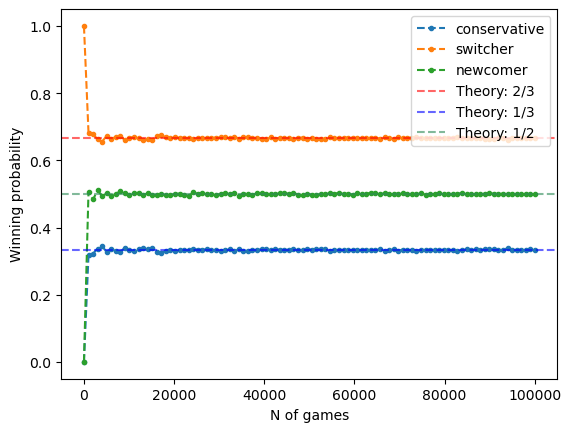

In [7]:
plt.plot(np.linspace(1,100000, 100).astype(int), conservative_prob, label= 'conservative', linestyle= '--', marker='.')
plt.plot(np.linspace(1,100000, 100).astype(int), switcher_prob, label='switcher', linestyle= '--', marker='.')
plt.plot(np.linspace(1,100000, 100).astype(int), newcomer_prob, label='newcomer', linestyle= '--', marker='.')
plt.axhline(y=2/3, color='red', linestyle='--', alpha=0.6, label='Theory: 2/3')
plt.axhline(y=1/3, color='blue', linestyle='--', alpha=0.6, label='Theory: 1/3')
plt.axhline(y=1/2, color='seagreen', linestyle='--', alpha=0.6, label='Theory: 1/2')
   
plt.legend()
plt.xlabel('N of games')
plt.ylabel('Winning probability')
#plt.xscale('log')
plt.show()

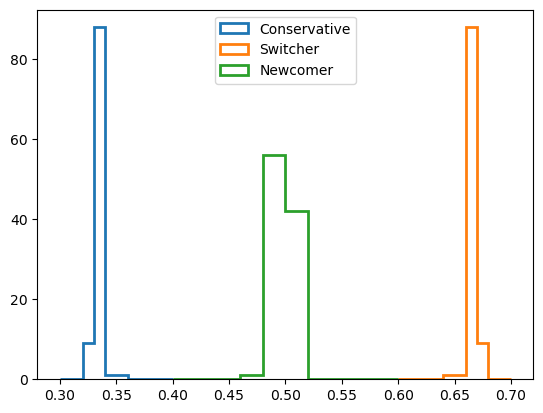

In [25]:
plt.hist(conservative_prob,histtype='step',lw=2,label='Conservative', range=(0.3,0.4))
plt.hist(switcher_prob,histtype='step',lw=2,label='Switcher',range=(0.6,0.7))
plt.hist(newcomer_prob,histtype='step',lw=2,label='Newcomer',range=(0.4,0.6))
plt.legend()

Running many times same 100 games simulation

In [12]:
conservative_prob = []
switcher_prob = []
newcomer_prob = []
N=100
for i in range(1000):
    c, s, n = simulate_monty_hall_3doors(N)
    conservative_prob.append(c)
    switcher_prob.append(s)
    newcomer_prob.append(n)

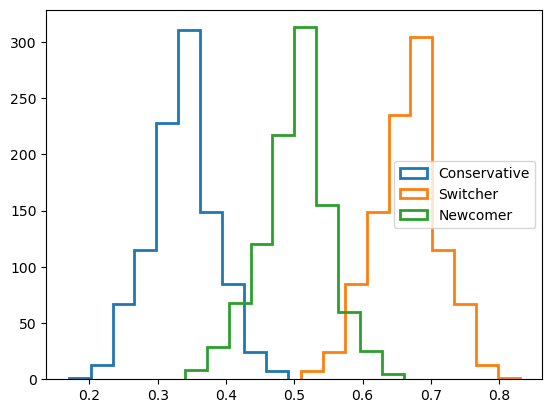

In [13]:
plt.hist(conservative_prob,histtype='step',lw=2,label='Conservative')#, range=(0.3,0.4), density='')
plt.hist(switcher_prob,histtype='step',lw=2,label='Switcher')#,range=(0.6,0.7))
plt.hist(newcomer_prob,histtype='step',lw=2,label='Newcomer')#,range=(0.4,0.6))
plt.legend()

Physical reasoning: Bayesian Analysis of Monty Hall (3 Doors)

Using Bayes' Theorem:
$$P(A|B) = \frac{P(B|A) P(A)}{P(B)}$$

Let's define the occuring events:
* $C_i$: The car is behind door $i$ (where $i \in \{1, 2, 3\}$).
* $H_j$: The host opens door $j$ (after we have chosen door 1).

Initial Probabilities (Priors):
$P(C_1) = P(C_2) = P(C_3) = 1/3$

Likelihoods (Given Door 1 chosen):
* $P(H_3 | C_1) = 1/2$ (If the car is behind door 1, the host can open either door 2 or 3).
* $P(H_3 | C_2) = 1$ (If the car is behind door 2, the host **must** open door 3).
* $P(H_3 | C_3) = 0$ (The host cannot open the door that has the car).

Posterior Probability (Winning by switching to Door 2):
Using the Law of Total Probability for the denominator $P(H_3)$:
$$P(H_3) = P(H_3|C_1)P(C_1) + P(H_3|C_2)P(C_2) + P(H_3|C_3)P(C_3)$$
$$P(H_3) = (1/2 \cdot 1/3) + (1 \cdot 1/3) + (0 \cdot 1/3) = 1/2$$

Now, applying Bayes for Door 2:
$$P(C_2 | H_3) = \frac{P(H_3 | C_2) P(C_2)}{P(H_3)} = \frac{1 \cdot 1/3}{1/2} = \frac{2}{3}$$



The probability of winning by switching is therefore $2/3$, while staying is only $1/3$.

Whilst the newcomer has $1/2$ chance to take the right door.

Food for thought: And what if you had N doors to choose from and the presenter opens p<N of them? Study how the probability of winning changes as a function of p and N.

In [26]:
def simulate_monty_hall_Ndoors(N, p, simulations = 100):
    conservative_wins = 0
    switcher_wins= 0
    newcomer_wins = 0
    for i in range(simulations):
        car = r.randint(0,N-1) #random selection of the car location
        doors = np.zeros(N).astype(int)
        doors[car]=1 #the array represents what is behind the doors (0 = goat, 1 = car)
        initial_choice = r.randint(0,N-1) #random choice by the player
        doors_left_to_open = [num for num in range(N) if num != car and num != initial_choice]
        #The presenter opens p of the doors
        opened_doors = r.sample(doors_left_to_open, p)
        
        #The switcher
        remaining_doors = [i for i in range(N) if i != initial_choice and i not in opened_doors]
        switcher_choice = r.choice(remaining_doors)
        #the newcomer
        newcomer_choice = r.choice([i for i in range(N) if i not in opened_doors])
        
        #check of winning
        if initial_choice == car:
            conservative_wins += 1
        if switcher_choice == car:
            switcher_wins += 1
        if newcomer_choice == car:
            newcomer_wins += 1
            
    return conservative_wins/simulations, switcher_wins/simulations, newcomer_wins/simulations  #returns fraction of winning

In [27]:
cons_prob, switch_prob, new_prob = simulate_monty_hall_Ndoors(50, 45, simulations = 100)

In [28]:
print(cons_prob, switch_prob, new_prob)

0.03 0.2 0.2


In [29]:
conservative_prob_pbig = []
switcher_prob_pbig = []
newcomer_prob_pbig = []
conservative_prob_psmall = []
switcher_prob_psmall = []
newcomer_prob_psmall = []
for N in np.linspace(10,1000, 10).astype(int):
    c, s, n = simulate_monty_hall_Ndoors(N, N-2, 1000)
    conservative_prob_pbig.append(c)
    switcher_prob_pbig.append(s)
    newcomer_prob_pbig.append(n)
    c, s, n = simulate_monty_hall_Ndoors(N, 1, 1000)
    conservative_prob_psmall.append(c)
    switcher_prob_psmall.append(s)
    newcomer_prob_psmall.append(n)

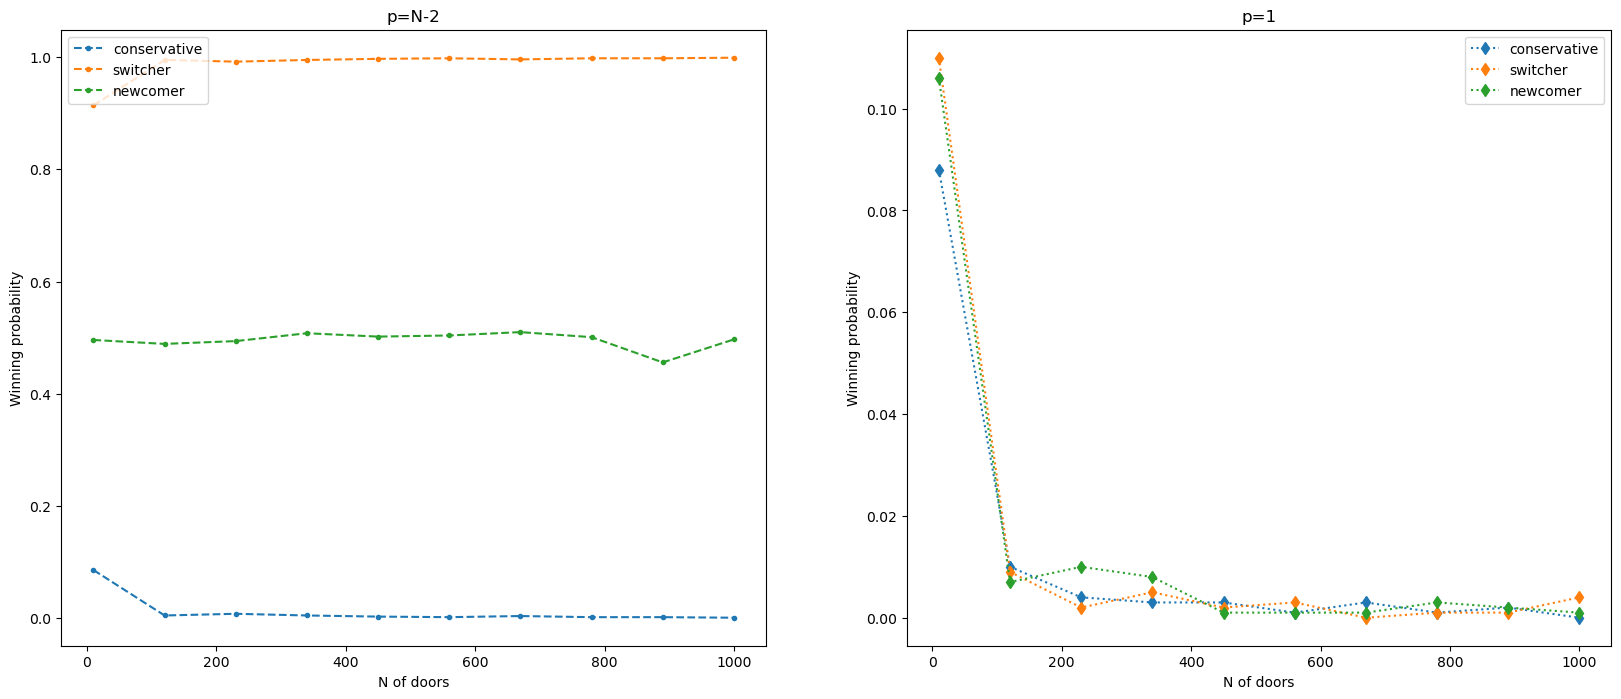

In [30]:
fig, ax =plt.subplots(1,2, figsize=(20,8))
ax[0].plot(np.linspace(10,1000, 10).astype(int), conservative_prob_pbig, label= 'conservative', linestyle= '--', marker='.')
ax[0].plot(np.linspace(10,1000, 10).astype(int), switcher_prob_pbig, label='switcher', linestyle= '--', marker='.')
ax[0].plot(np.linspace(10,1000, 10).astype(int), newcomer_prob_pbig, label='newcomer', linestyle= '--', marker='.')
ax[1].plot(np.linspace(10,1000, 10).astype(int), conservative_prob_psmall, label= 'conservative', linestyle= 'dotted', marker='d')
ax[1].plot(np.linspace(10,1000, 10).astype(int), switcher_prob_psmall, label='switcher', linestyle= 'dotted', marker='d')
ax[1].plot(np.linspace(10,1000, 10).astype(int), newcomer_prob_psmall, label='newcomer', linestyle= 'dotted', marker='d')
ax[0].legend()
ax[0].set_title('p=N-2')
ax[1].set_title('p=1')
ax[0].set_xlabel('N of doors')
ax[0].set_ylabel('Winning probability')
ax[1].legend()
ax[1].set_xlabel('N of doors')
ax[1].set_ylabel('Winning probability')

plt.show()

In [31]:
conservative_prob = []
switcher_prob = []
newcomer_prob = []
N=50
for p in np.linspace(1,N-2, N-2).astype(int):
    c, s, n = simulate_monty_hall_Ndoors(N, p)
    conservative_prob.append(c)
    switcher_prob.append(s)
    newcomer_prob.append(n)

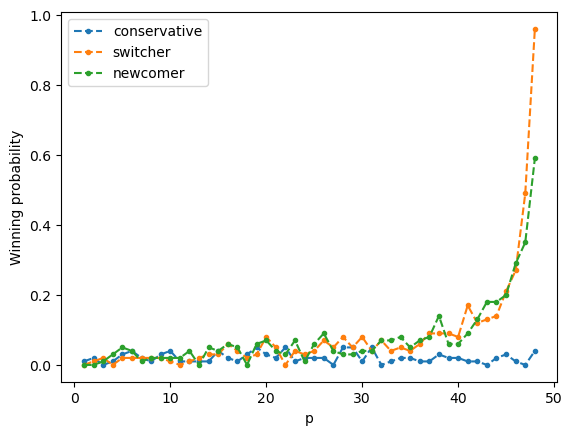

In [55]:
plt.plot(np.linspace(1,N-2, N-2).astype(int), conservative_prob, label= 'conservative', linestyle= '--', marker='.')
plt.plot(np.linspace(1,N-2, N-2).astype(int), switcher_prob, label='switcher', linestyle= '--', marker='.')
plt.plot(np.linspace(1,N-2, N-2).astype(int), newcomer_prob, label='newcomer', linestyle= '--', marker='.')
plt.legend()
plt.xlabel('p')
plt.ylabel('Winning probability')
plt.show()

Physical reasoning: The Generalized Bayesian Perspective ($N$ doors, $p$ open)

In the general case, the host provides information by eliminating $p$ incorrect choices. 

The Bayesian update remains the same in principle:
1. The Prior $P(C_{initial}) = 1/N$.
2. The remaining probability $(1 - 1/N)$ is initially distributed among $(N-1)$ doors.
3. After the host opens $p$ doors, that same $(1 - 1/N)$ probability mass is now concentrated into the remaining $(N - 1 - p)$ doors.

The updated probability for each remaining door is:
$$P(\text{win by switching}) = \frac{1 - 1/N}{N - 1 - p} = \frac{N-1}{N(N-p-1)}$$

Limiting cases:
* If $p = 0$ (Host opens nothing): $P = \frac{N-1}{N(N-1)} = 1/N$ (No advantage to switching).
* If $p = N-2$ (Host opens all but one): $P = \frac{N-1}{N(1)} = 1 - 1/N$ (Massive advantage).

# Pdf of the log
Use numpy to draw N (where is large...) random samples from a uniform distribution between 0.1 and 10, and store these samples as x.
Use matplotlib to make a histogram of these samples.
Compute the base-10 log of your array x, and store this as y.
Make another histogram for y. Using the equation to transform probability distributions, write what the theoretical pdf of y is, and overplot it onto your histogram.
Compute the log of the mean of x and the mean of y. Now compute the log of the median of x and the median of y.

Physical reasoning: You should note that the means are different, but the medians (as it is a cumulative statistic) are the same. The mean is affected by the scale of the sample values, but the median only depends on the ordering of the samples. Monotonic transformations (like taking the log) do not change the ordering of samples.

Text(0, 0.5, 'Densità')

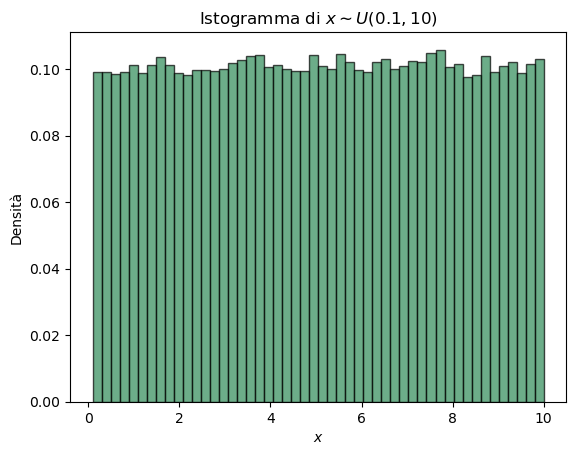

In [58]:
N = 100000
a, b = 0.1, 10
x = np.random.uniform(a, b, N)
plt.hist(x, bins=50, density=True, color='seagreen', edgecolor='black', alpha=0.7)
plt.title('Histogram of $x \sim U(0.1, 10)$')
plt.xlabel('$x$')
plt.ylabel('Density')

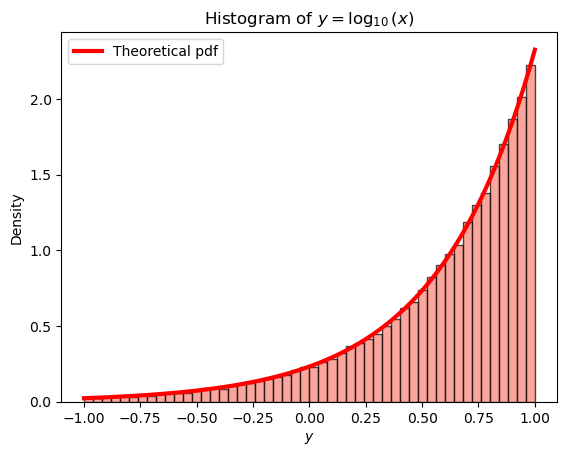

In [59]:
y = np.log10(x)

plt.hist(y, bins=50, density=True, color='salmon', edgecolor='black', alpha=0.7)

# Theoretical pdf: f_Y(y) = (10^y * ln(10)) / (b - a)
y_range = np.linspace(np.log10(a), np.log10(b), 200)
pdf_y = (10**y_range * np.log(10)) / (b - a)

plt.plot(y_range, pdf_y, 'r-', lw=3, label='Theoretical pdf')
plt.title('Histogram of $y = \log_{10}(x)$')
plt.xlabel('$y$')
plt.ylabel('Density')
plt.legend()

plt.show()

In [60]:
log_mean_x = np.log10(np.mean(x))
mean_y = np.mean(y)
log_median_x = np.log10(np.median(x))
median_y = np.median(y)

print(f"Log mean of x: {log_mean_x:.4f}")
print(f"Mean of y (log10(x)): {mean_y:.4f}")
print(f"Log median of x: {log_median_x:.4f}")
print(f"Median of y (log10(x)): {median_y:.4f}")

Log mean of x: 0.7044
Mean of y (log10(x)): 0.5882
Log median of x: 0.7048
Median of y (log10(x)): 0.7048


## Theoretical Derivation of the PDF of $y$

To find the probability density function (PDF) of a transformed variable, the principle of conservation of probability has been used:
$$|f_Y(y) dy| = |f_X(x) dx| \implies f_Y(y) = f_X(x) \left| \frac{dx}{dy} \right|$$

Given the initial distribution $x \sim U(a, b)$:
* The original PDF is $f_X(x) = \frac{1}{b - a}$ for $x \in [0.1, 10]$.
* the transformation is $y = \log_{10}(x)$, which implies the inverse function $x = 10^y$.
* The Jacobian of the transformation is:
    $$\frac{dx}{dy} = \frac{d}{dy}(10^y) = 10^y \ln(10)$$



Substituting these into the formula, the theoretical PDF for $y$ becomes:
$$f_Y(y) = \frac{\ln(10) \cdot 10^y}{b - a} \quad \text{for } y \in [\log_{10}(a), \log_{10}(b)]$$

This exponential shape in the log-plot explains why the histogram of $y$ is not flat, even though $x$ was uniform.

##  Physical Reasoning: Means vs. Medians

### 1. The Means are different
 $\log_{10}(\langle x \rangle) \neq \langle \log_{10}(x) \rangle$. 
The mean is a linear operator, but the logarithm is a concave function. 
According to Jensen's Inequality, the logarithm of the average is always greater than or equal to the average of the logarithms. The mean is sensitive to the "scale" and the specific values of the distribution.

### 2. The Medians are the same
$\log_{10}(\text{median}(x)) \approx \text{median}(y)$.
The median is a cumulative statistic based on the ordering (ranking) of the data. 
Since the logarithm is a monotonic transformation (it preserves the order of values), the data point that was at the 50th percentile in the $x$ distribution remains at the 50th percentile in the $y$ distribution. 

Monotonic transformations do not change the relative ordering of samples, making the median a more robust statistic for comparing distributions across different scales (like linear vs. log scales).